## 5.ANN-Classification
---
#### Business Problem
- Whether customer will churn/exist or not

In [1]:
import numpy as np
import pandas as pd

In [2]:
## Churn Modelling to predict whether the customer will leave the bank  or not
df = pd.read_csv("Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [3]:
# no. of unique values in each column
df["Exited"].unique() # Binary Classification

array([1, 0])

**Data Understanding**

In [4]:
df.columns.to_list()

['RowNumber',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [5]:
print("Geography:", df["Geography"].nunique())
print("Gender:", df["Gender"].nunique())
print("HasCrCard:", df["HasCrCard"].nunique())
print("IsActiveMember:", df["IsActiveMember"].nunique())
print("NumOfProducts:", df["NumOfProducts"].nunique())
print("Tenure:", df["Tenure"].nunique())
print("CreditScore:", df["CreditScore"].nunique())
print("Age:", df["Age"].nunique())
print("Balance:", df["Balance"].nunique())
print("EstimatedSalary:", df["EstimatedSalary"].nunique())
print("Exited:", df["Exited"].nunique())

Geography: 3
Gender: 2
HasCrCard: 2
IsActiveMember: 2
NumOfProducts: 4
Tenure: 11
CreditScore: 460
Age: 70
Balance: 6382
EstimatedSalary: 9999
Exited: 2


**Data Cleaning**

In [6]:
df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [7]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [8]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [9]:
X = pd.get_dummies(df.drop('Exited',axis=1), drop_first=True)
y = df['Exited']

In [10]:
### Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X , y, test_size=0.2, random_state=0)

In [11]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [12]:
x_train.shape , x_test.shape , y_train.shape , y_test.shape

((8000, 11), (2000, 11), (8000,), (2000,))

In [13]:
# Scaling is applied only to classification problems and not to regression problems because in regression problems, the output variable is continuous and can take any value. So we do not need to scale the features in regression problems. 
# But in classification problems, the output variable is categorical and can take only a limited number of values. So we need to scale the features in classification problems to bring all the features to the same scale.
## Scaling is the solution to the problem of different scales of the features. ANN is sensitive to the scale of the data. So we need to scale the features before training the ANN.
## Scaling  means that we will bring all the features to the same scale. This is done by subtracting the mean and dividing by the standard deviation. This will bring all the features to a scale of 0 to 1.
## Scaling the features because ANN is sensitive to the scale of the data
## Here in this dataset, the features are in different scales. So we will scale the features using StandardScaler
## Balance and EstimatedSalary are in different scales. So we will scale these features.
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
## In scalling we fit the scaler on the training data and then transform both the training and test data. This is to avoid data leakage from the test set to the training set.
## Scalinfg is done to bring all the features to the same scale so that the ANN can learn effectively. If we do not scale the features, then the ANN may give more importance to the features which are in higher scales and less importance to the features which are in lower scales. This can lead to poor performance of the model.

##### Data Modelling
**Initializing the Artificial Neural Network**

In [14]:
import tensorflow as tf
import keras

from keras.models import Sequential
from keras.layers import Dense

In [15]:
## Initialising the ANN
p_model = Sequential()

# Hidden layer with relu activation function and output layer with sigmoid activation function
p_model.add(Dense(input_dim=11, units = 22, activation='relu', kernel_initializer='uniform'))
p_model.add(Dense(units=22, activation='relu', kernel_initializer='uniform'))
p_model.add(Dense(units=1, activation='sigmoid', kernel_initializer='uniform'))

p_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## training the ANN on the Training set
p_model.fit(x_train, y_train, batch_size=32, epochs=100)

Epoch 1/100


c:\Users\nirmi\anaconda3\envs\dl_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7943 - loss: 0.5158  
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7960 - loss: 0.4267  
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step - accuracy: 0.8164 - loss: 0.4195
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8307 - loss: 0.4126
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8326 - loss: 0.4070   
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8338 - loss: 0.4047  
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - accuracy: 0.8355 - loss: 0.4009
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8342 - loss: 0.3995  
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8355 - loss: 0.3977  
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8347 - loss: 0.3968  
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step - accuracy: 0.8359 - loss: 0.3957
Epoch 12/100
250/250 ━━━━━━━━━━━

**Predictions**

In [16]:
y_pred_train = p_model.predict(x_train)
y_pred_train = (y_pred_train >= 0.5)

y_pred_test = p_model.predict(x_test)
y_pred_test = (y_pred_test >= 0.5)

# Above code is for training the ANN and making predictions on the training and test set. 
# We have used sigmoid activation function in the output layer because we are doing binary classification. 
# We have used binary_crossentropy as the loss function because we are doing binary classification.
# We have used adam optimizer because it is a good optimizer for training neural networks. 
# We have used accuracy as the metric to evaluate the performance of the model.

# >= 0.5 is used to convert the predicted probabilities into binary values. 
# If the predicted probability is greater than or equal to 0.5, then we will classify it as 1 (customer will leave the bank), otherwise we will classify it as 0 (customer will not leave the bank).

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 778us/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


**Evaluations**

In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
# Above code is for evaluating the performance of the model using confusion matrix and accuracy score.
# We can see that the accuracy on the training set is 0.85 and the accuracy on the test set is 0.86. This means that our model is performing well on both the training and test set.

Train Accuracy: 0.87125
Test Accuracy: 0.854


##### Predictions & Evaluation the Model
**Predictions**

In [18]:
y_pred = p_model.predict(x_test)
y_pred = (y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 858us/step


**Evaluations**

In [19]:
from sklearn.metrics import confusion_matrix, accuracy_score

print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

confusion_matrix(y_test, y_pred)
# confusion matrix is a table that is used to evaluate the performance of a classification model. It is a 2x2 matrix that shows the number of true positives, true negatives, false positives, and false negatives.
# The confusion matrix shows that there are 1525 true negatives (TN), 70 false positives (FP), 309 false negatives (FN), and 96 true positives (TP).
#          Predicted
#          0   1
# Actual 0 
#        1
# TN -> 1525 (customer will not leave the bank and the model predicted that the customer will not leave the bank)
# FP -> 70 (customer will not leave the bank but the model predicted that the customer will leave the bank)
# FN -> 309 (customer will leave the bank but the model predicted that the customer will not leave the bank)
# TP -> 96 (customer will leave the bank and the model predicted that the customer will leave the bank)

# 1526 + 96 = 1621 (total number of customers who will not leave the bank) Correctly Predicted
# 70 + 309 = 379 (total number of customers who will leave the bank ) Incorrectly Predicted

# accuracy = (TN + TP) / (TN + FP + FN + TP)
# accuracy = (1525 + 96) / (1525 + 70 + 309 + 96)
# accuracy = 1621 / 2000 = 0.8105

Train Accuracy: 0.87125
Test Accuracy: 0.854


array([[1500,   95],
       [ 197,  208]])

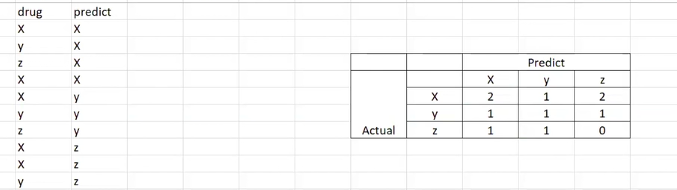

##### Cross Validate the Model
Cross Validation - Here we will use k-fold cross validation to evaluate the performance of the model.
In k-fold cross validation, we will split the dataset into k folds and then we will train the model on 
k-1 folds and test the model on the remaining fold. We will repeat this process k times and then we will take the average of the accuracy scores to get the final accuracy score of the model. This is a better way to evaluate the performance of the model because it gives us a better estimate of the accuracy of the model on unseen data.

In [20]:
def build_cross_classifier():
    p_model = Sequential()
    p_model.add(Dense(input_dim = 11, units = 6, kernel_initializer = 'uniform', activation = 'relu'))
    p_model.add(Dense(units = 6, kernel_initializer = 'uniform', activation = 'relu'))
    p_model.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))
    p_model.compile(optimizer = "adam", loss = 'binary_crossentropy', metrics = ['accuracy'])
    return p_model

In [24]:
from scikeras.wrappers import KerasClassifier
cross_classifier = KerasClassifier(build_fn = build_cross_classifier, batch_size = 10, epochs = 100)

In [25]:
from sklearn.model_selection import cross_val_score
cross_val_score(estimator = cross_classifier, X = x_train, y = y_train, cv = 5, scoring = 'accuracy').mean()

Epoch 1/100


c:\Users\nirmi\anaconda3\envs\dl_env\lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\nirmi\anaconda3\envs\dl_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 975us/step - accuracy: 0.7972 - loss: 0.4925
Epoch 2/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7980 - loss: 0.4271
Epoch 3/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7980 - loss: 0.4224
Epoch 4/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8062 - loss: 0.4190
Epoch 5/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8236 - loss: 0.4165
Epoch 6/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8269 - loss: 0.4155
Epoch 7/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 975us/step - accuracy: 0.8286 - loss: 0.4137
Epoch 8/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 968us/step - accuracy: 0.8292 - loss: 0.4126
Epoch 9/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8306 - loss: 0.4122  
Epoch 10/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 970us/step - accuracy: 0.8325 - loss: 0.4111
Epoch 11/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 943us/step - accuracy: 0.8328 - loss: 0.4108
Epoch 12/100
640/640 ━━━━━━━━━━━━━━━━━━━━

c:\Users\nirmi\anaconda3\envs\dl_env\lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\nirmi\anaconda3\envs\dl_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7966 - loss: 0.5018  
Epoch 2/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 966us/step - accuracy: 0.7972 - loss: 0.4283
Epoch 3/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 956us/step - accuracy: 0.7972 - loss: 0.4227
Epoch 4/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 967us/step - accuracy: 0.8042 - loss: 0.4181
Epoch 5/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 942us/step - accuracy: 0.8247 - loss: 0.4160
Epoch 6/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 976us/step - accuracy: 0.8275 - loss: 0.4140
Epoch 7/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 947us/step - accuracy: 0.8309 - loss: 0.4124
Epoch 8/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 938us/step - accuracy: 0.8333 - loss: 0.4110
Epoch 9/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8363 - loss: 0.4102  
Epoch 10/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 955us/step - accuracy: 0.8345 - loss: 0.4092
Epoch 11/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 935us/step - accuracy: 0.8353 - loss: 0.4079
Epoch 12/100
640/640 ━━━━━━━━━━

...

c:\Users\nirmi\anaconda3\envs\dl_env\lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\nirmi\anaconda3\envs\dl_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7970 - loss: 0.4943  
Epoch 2/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 989us/step - accuracy: 0.7973 - loss: 0.4290
Epoch 3/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1000us/step - accuracy: 0.7973 - loss: 0.4239
Epoch 4/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8050 - loss: 0.4195  
Epoch 5/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 977us/step - accuracy: 0.8236 - loss: 0.4159
Epoch 6/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 987us/step - accuracy: 0.8266 - loss: 0.4146
Epoch 7/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8306 - loss: 0.4128  
Epoch 8/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 990us/step - accuracy: 0.8317 - loss: 0.4117
Epoch 9/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 988us/step - accuracy: 0.8328 - loss: 0.4108
Epoch 10/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 984us/step - accuracy: 0.8342 - loss: 0.4097
Epoch 11/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8341 - loss: 0.4088  
Epoch 12/100
640/640 ━━━━━━━━━

c:\Users\nirmi\anaconda3\envs\dl_env\lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\nirmi\anaconda3\envs\dl_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7956 - loss: 0.4956
Epoch 2/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8105 - loss: 0.4226
Epoch 3/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8272 - loss: 0.4165
Epoch 4/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8302 - loss: 0.4118
Epoch 5/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8297 - loss: 0.4085
Epoch 6/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8317 - loss: 0.4029
Epoch 7/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8309 - loss: 0.3956
Epoch 8/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8327 - loss: 0.3885
Epoch 9/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8370 - loss: 0.3823
Epoch 10/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8420 - loss: 0.3778
Epoch 11/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8423 - loss: 0.3731
Epoch 12/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

np.float64(0.8396250000000001)

#### Improving and Tuning the ANN
**This can be done by using 3 options**
1. Hyperparameter Tuning
2. Regularization (L1 & L2) to reduce overfitting if needed (for Regression problems)
3. Dropout

**Hyperparameter tuning can be done for identifying no.of hidden layers & no.of neurons in each hidden layer**
- layers = [[20],[10],[30],[40]] --> 1 hidden layer with different options of no.of neurons in that hidden layer
- layers = [[20],[40,20],[45,30,15]] --> Multiple hidden layers with different options of no.of neurons

**Hyperparameter tuning can be done for identifying best activation function for hidden layers**
- activations=['relu','sigmoid']

**Hyperparameter tuning can be done for identifying best optimizers**
- optimizer =['adam','rmsprop']

**Hyperparameter tuning can be done for identifying best batchsize for building/training model**
- batchsize =[10,16,32,64,128,256]

In [26]:
estimator = KerasClassifier(build_cross_classifier())
param_grid = {'batch_size': [10, 32], 'epochs': [50, 100] , 'optimizer': ['adam', 'rmsprop']}

c:\Users\nirmi\anaconda3\envs\dl_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator = estimator, param_grid = param_grid, scoring = 'accuracy', cv = 5)
grid_results = grid_search.fit(x_train, y_train)

Epoch 1/50


c:\Users\nirmi\anaconda3\envs\dl_env\lib\site-packages\keras\src\saving\saving_lib.py:794: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 941us/step - accuracy: 0.7975 - loss: 0.5030
Epoch 2/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 986us/step - accuracy: 0.7980 - loss: 0.4302
Epoch 3/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7980 - loss: 0.4253  
Epoch 4/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7980 - loss: 0.4225
Epoch 5/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7994 - loss: 0.4201
Epoch 6/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8220 - loss: 0.4175
Epoch 7/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8281 - loss: 0.4153
Epoch 8/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8289 - loss: 0.4145
Epoch 9/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8322 - loss: 0.4132
Epoch 10/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8311 - loss: 0.4123
Epoch 11/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8331 - loss: 0.4110
Epoch 12/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - ac

In [28]:
#best parameters
grid_results.best_params_

{'batch_size': 32, 'epochs': 100, 'optimizer': 'rmsprop'}

In [29]:
#best accuracy
grid_results.best_score_

np.float64(0.85625)